In [1]:
import pandas as pd

print(pd.__version__)


2.3.3


In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [8]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.isnull().sum().sum()

np.int64(0)

In [10]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

<Axes: xlabel='Churn'>

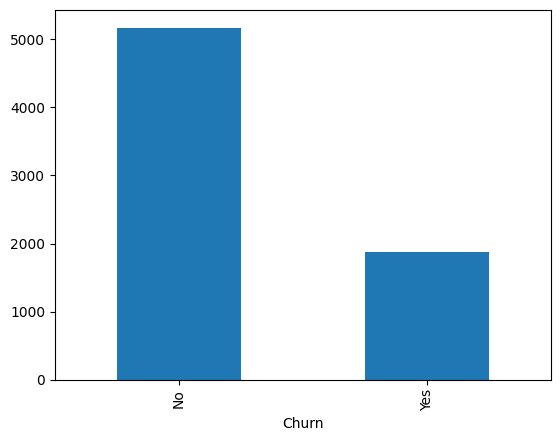

In [11]:
df['Churn'].value_counts().plot(kind='bar')

In [12]:
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<Axes: xlabel='tenure'>

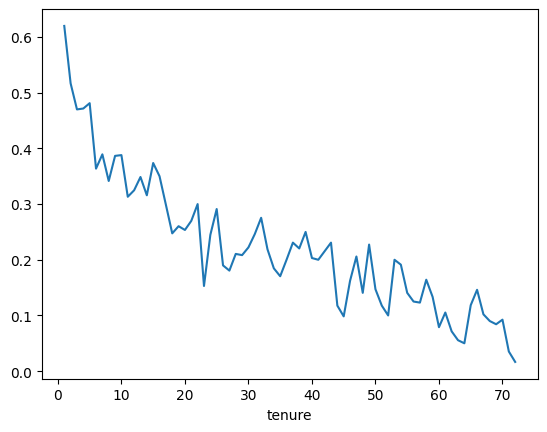

In [13]:
df.groupby('tenure')['Churn'].value_counts(normalize=True).unstack()['Yes'].plot()

In [14]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [15]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [16]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [17]:
df.drop('customerID', axis=1, inplace=True)
df.shape

(7043, 20)

In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.shape

(7043, 31)

In [19]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((5634, 30), (1409, 30))

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
model.score(X_test, y_test)

c:\Users\mogal\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8211497515968772

In [21]:
from sklearn.metrics import classification_report

In [22]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [23]:
#import xgboost
import xgboost
print(xgboost.__version__)

2.1.4


In [24]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_model.score(X_test, y_test)

0.7984386089425124

In [25]:
print(classification_report(y_test, xgb_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1036
           1       0.64      0.54      0.58       373

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [26]:
import shap
print(shap.__version__)

c:\Users\mogal\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.49.1


In [27]:
import shap

In [28]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

In [29]:
explainer = shap.TreeExplainer(xgb_model)

In [30]:
import xgboost
print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)

XGBoost: 2.1.4
SHAP: 0.49.1


In [31]:
import shap
print(shap.__version__)

0.49.1


In [32]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

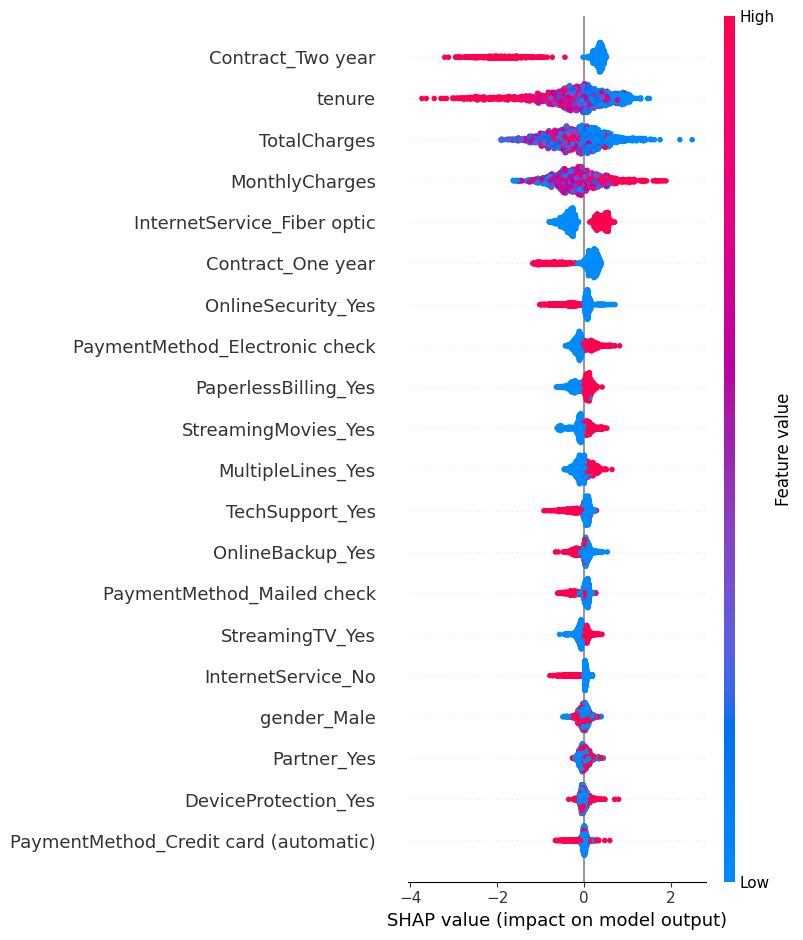

In [33]:
shap.summary_plot(shap_values, X_test)

In [34]:
X_test_copy = X_test.copy()
X_test_copy['churn_prob'] = xgb_model.predict_proba(X_test)[:, 1]
X_test_copy['MonthlyCharges'] = df.loc[X_test.index, 'MonthlyCharges']
X_test_copy[['churn_prob', 'MonthlyCharges']].head()

,churn_prob,MonthlyCharges
185,0.731425,24.80
2715,0.176481,25.25
3825,0.013885,19.35
1807,0.966820,76.35
132,0.001874,50.55


In [ ]:
at_risk_revenue = X_test_copy[X_test_copy['churn_prob'] > 0.5]['MonthlyCharges'].sum()
print(f"Monthly revenue at risk: ${at_risk_revenue:,.2f}")

# Monthly revenue at risk: $23,893.55

Monthly revenue at risk: $23,893.55


In [ ]:
top20_cutoff = X_test_copy['churn_prob'].quantile(0.80)
top20 = X_test_copy[X_test_copy['churn_prob'] >= top20_cutoff]
top20_revenue = top20['MonthlyCharges'].sum()
print(f"Customers in top 20% risk: {len(top20)}")
print(f"Their monthly revenue: ${top20_revenue:,.2f}")


#Customers in top 20% risk: 282
#Their monthly revenue: $21,771.50

Customers in top 20% risk: 282
Their monthly revenue: $21,771.50


In [ ]:
retention_rate = 0.30
estimated_savings = top20_revenue * retention_rate
print(f"Estimated monthly revenue saved: ${estimated_savings:,.2f}")
print(f"Estimated annual revenue saved: ${estimated_savings * 12:,.2f}")



#Estimated monthly revenue saved: $6,531.45
#Estimated annual revenue saved: $78,377.40

Estimated monthly revenue saved: $6,531.45
Estimated annual revenue saved: $78,377.40


In [38]:
summary = f"""
CHURN PROJECT — KEY RESULTS
- Dataset: {df.shape[0]} customers, {df.shape[1]} features
- Overall churn rate: {(df['Churn'].mean()*100):.1f}%
- Logistic Regression accuracy: {model.score(X_test, y_test):.2f}
- XGBoost accuracy: {xgb_model.score(X_test, y_test):.2f}
- Monthly revenue at risk (all flagged): ${at_risk_revenue:,.2f}
- Top 20% riskiest customers: {len(top20)} customers, ${top20_revenue:,.2f}/month
- Estimated annual savings (30% retention): ${estimated_savings*12:,.2f}
"""
print(summary)

with open('summary.txt', 'w') as f:
    f.write(summary)


CHURN PROJECT — KEY RESULTS
- Dataset: 7043 customers, 20 features
- Overall churn rate: 26.5%
- Logistic Regression accuracy: 0.82
- XGBoost accuracy: 0.80
- Monthly revenue at risk (all flagged): $23,893.55
- Top 20% riskiest customers: 282 customers, $21,771.50/month
- Estimated annual savings (30% retention): $78,377.40



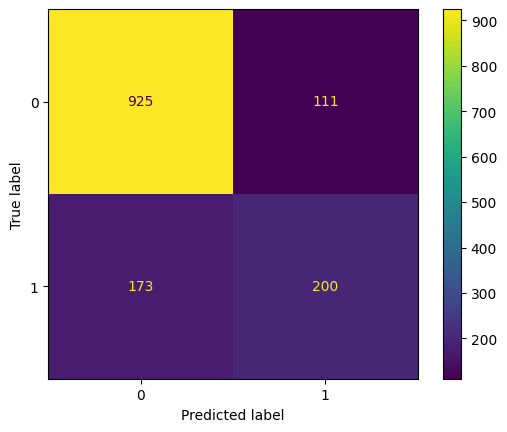

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test)

In [40]:
import joblib
joblib.dump(xgb_model, 'churn_model.pkl')

['churn_model.pkl']

In [41]:
top20_export = top20[['churn_prob', 'MonthlyCharges']].sort_values('churn_prob', ascending=False)
top20_export.to_csv('top_risk_customers.csv')
print("Saved", len(top20_export), "customers to top_risk_customers.csv")

Saved 282 customers to top_risk_customers.csv


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

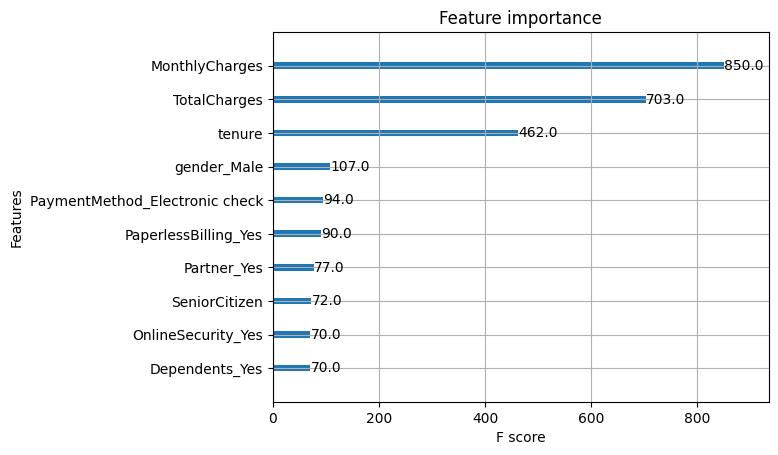

In [42]:
from xgboost import plot_importance
plot_importance(xgb_model, max_num_features=10)